# Odd-even closure diagnostics for pure triadic two-group chimera model

이 노트북은 다음을 확인하기 위한 전체 코드입니다.

1. Microscopic finite-$N$ simulation
2. Two-mode odd-even closure
   $$A_\sigma=Z_{\sigma,2},\quad B_\sigma=Z_{\sigma,1},\quad Z_{\sigma,3}\approx A_\sigma B_\sigma$$
3. Three-mode closure
   $$A_\sigma=Z_{\sigma,2},\quad B_\sigma=Z_{\sigma,1},\quad C_\sigma=Z_{\sigma,3}$$
4. $Z_3$ closure error
   $$D_{\sigma,3}=Z_{\sigma,3}-Z_{\sigma,1}Z_{\sigma,2}$$
5. Dynamic leakage into the $B_\sigma$ equation
   $$L_{\sigma,3}=\frac12 |H_\sigma|\, |Z_{\sigma,3}-Z_{\sigma,1}Z_{\sigma,2}|$$

`solve_ivp`는 사용하지 않고, 모든 적분은 fixed-step RK4로 수행합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path('odd_even_outputs')
OUTDIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 300

## 1. Parameters

In [25]:
# Model parameters
alpha = 0.7
mu = 0.5
omega = 0.0

# Finite-N size
N1 = 3000
N2 = 3000

# Initial condition
Q1_0 = 1.0
Q2_0 = 0.6
eta1_0 = 0.35
eta2_0 = 0.53
psi1_0 = 0.0
psi2_0 = 0.0

# Integration
dt = 0.05
tmax = 1500.0
record_every = 2
seed = 7

EPS = 1e-12

## 2. Utility functions

In [26]:
def wrap_angle(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi

def wrap_phase(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi

def sample_wrapped_cauchy(n, rho, mean=0.0, rng=None):
    """Wrapped Cauchy with <exp(i theta)> = rho exp(i mean)."""
    if rng is None:
        rng = np.random.default_rng()
    if n <= 0:
        return np.empty(0)
    if rho >= 1.0 - 1e-14:
        return np.full(n, wrap_angle(mean))
    u = rng.random(n)
    theta = mean + 2.0*np.arctan(((1-rho)/(1+rho))*np.tan(np.pi*(u-0.5)))
    return wrap_angle(theta)

def make_bimodal_initial_condition(N, Q, eta, psi=0.0, rng=None):
    """
    Bimodal OA-like initial condition.

    Approximately:
        A = <exp(2 i theta)> ~ Q exp(2 i psi)
        B = <exp(i theta)> ~ (1 - 2 eta) sqrt(Q) exp(i psi)
    """
    if rng is None:
        rng = np.random.default_rng()
    rho = np.sqrt(Q)
    n0 = int(round((1.0 - eta) * N))
    npi = N - n0
    theta0 = sample_wrapped_cauchy(n0, rho, psi, rng)
    thetapi = sample_wrapped_cauchy(npi, rho, psi, rng) + np.pi
    theta = wrap_angle(np.concatenate([theta0, thetapi]))
    rng.shuffle(theta)
    return theta

def order_moments(theta):
    """Return A=Z2, B=Z1, C=Z3."""
    B = np.mean(np.exp(1j*theta))
    A = np.mean(np.exp(2j*theta))
    C = np.mean(np.exp(3j*theta))
    return A, B, C

def safe_complex_sqrt(z, eps=1e-14):
    return np.sqrt(z + eps)

def b_from_A_B(A, B):
    return B / safe_complex_sqrt(A)

def eta_eff_from_A_B(A, B):
    b = b_from_A_B(A, B)
    return 0.5 * (1.0 - np.real(b))

def xi_from_A_B(A, B):
    return wrap_phase(np.angle(B) - 0.5*np.angle(A))

def rms(x):
    return float(np.sqrt(np.mean(np.asarray(x)**2)))

## 3. Microscopic finite-$N$ dynamics

Pure triadic two-group dynamics:

$$\dot\theta_i^\sigma=\omega+\operatorname{Im}[H_\sigma e^{-2i\theta_i^\sigma}]$$

with

$$H_1=e^{-i\alpha}(B_1+\mu B_2)^2,\quad H_2=e^{-i\alpha}(B_2+\mu B_1)^2.$$

In [27]:
def microscopic_fields(theta1, theta2, alpha, mu):
    _, B1, _ = order_moments(theta1)
    _, B2, _ = order_moments(theta2)
    H1 = np.exp(-1j*alpha) * (B1 + mu*B2)**2
    H2 = np.exp(-1j*alpha) * (B2 + mu*B1)**2
    return H1, H2

def micro_rhs(theta1, theta2, alpha, mu, omega):
    H1, H2 = microscopic_fields(theta1, theta2, alpha, mu)
    dtheta1 = omega + np.imag(H1 * np.exp(-2j*theta1))
    dtheta2 = omega + np.imag(H2 * np.exp(-2j*theta2))
    return dtheta1, dtheta2

def rk4_micro_step(theta1, theta2, dt, alpha, mu, omega):
    k1_1, k1_2 = micro_rhs(theta1, theta2, alpha, mu, omega)
    k2_1, k2_2 = micro_rhs(theta1 + 0.5*dt*k1_1, theta2 + 0.5*dt*k1_2, alpha, mu, omega)
    k3_1, k3_2 = micro_rhs(theta1 + 0.5*dt*k2_1, theta2 + 0.5*dt*k2_2, alpha, mu, omega)
    k4_1, k4_2 = micro_rhs(theta1 + dt*k3_1, theta2 + dt*k3_2, alpha, mu, omega)
    theta1_new = theta1 + dt*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)/6.0
    theta2_new = theta2 + dt*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)/6.0
    return wrap_angle(theta1_new), wrap_angle(theta2_new)

## 4. Two-mode odd-even closure

Two-mode closure uses

$$A_\sigma=Z_{\sigma,2},\quad B_\sigma=Z_{\sigma,1},\quad Z_{\sigma,3}\approx A_\sigma B_\sigma.$$

In [28]:
def closure2_rhs(y, alpha, mu, omega):
    """Two-mode closure: y = [A1, B1, A2, B2]."""
    A1, B1, A2, B2 = y
    H1 = np.exp(-1j*alpha) * (B1 + mu*B2)**2
    H2 = np.exp(-1j*alpha) * (B2 + mu*B1)**2
    dA1 = 2j*omega*A1 + H1 - np.conj(H1)*A1**2
    dA2 = 2j*omega*A2 + H2 - np.conj(H2)*A2**2
    dB1 = 1j*omega*B1 + 0.5*H1*np.conj(B1) - 0.5*np.conj(H1)*B1*A1
    dB2 = 1j*omega*B2 + 0.5*H2*np.conj(B2) - 0.5*np.conj(H2)*B2*A2
    return np.array([dA1, dB1, dA2, dB2], dtype=complex)

def rk4_closure2_step(y, dt, alpha, mu, omega):
    k1 = closure2_rhs(y, alpha, mu, omega)
    k2 = closure2_rhs(y + 0.5*dt*k1, alpha, mu, omega)
    k3 = closure2_rhs(y + 0.5*dt*k2, alpha, mu, omega)
    k4 = closure2_rhs(y + dt*k3, alpha, mu, omega)
    return y + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

## 5. Three-mode closure

To include the $Z_1$-$Z_3$ difference, use

$$A_\sigma=Z_{\sigma,2},\quad B_\sigma=Z_{\sigma,1},\quad C_\sigma=Z_{\sigma,3}$$

and close the next odd moment as

$$Z_{\sigma,5}\approx C_\sigma A_\sigma.$$

In [29]:
def closure3_rhs(y, alpha, mu, omega):
    """Three-mode closure: y = [A1, B1, C1, A2, B2, C2]."""
    A1, B1, C1, A2, B2, C2 = y
    H1 = np.exp(-1j*alpha) * (B1 + mu*B2)**2
    H2 = np.exp(-1j*alpha) * (B2 + mu*B1)**2
    dA1 = 2j*omega*A1 + H1 - np.conj(H1)*A1**2
    dA2 = 2j*omega*A2 + H2 - np.conj(H2)*A2**2
    dB1 = 1j*omega*B1 + 0.5*(H1*np.conj(B1) - np.conj(H1)*C1)
    dB2 = 1j*omega*B2 + 0.5*(H2*np.conj(B2) - np.conj(H2)*C2)
    dC1 = 3j*omega*C1 + 1.5*(H1*B1 - np.conj(H1)*C1*A1)
    dC2 = 3j*omega*C2 + 1.5*(H2*B2 - np.conj(H2)*C2*A2)
    return np.array([dA1, dB1, dC1, dA2, dB2, dC2], dtype=complex)

def rk4_closure3_step(y, dt, alpha, mu, omega):
    k1 = closure3_rhs(y, alpha, mu, omega)
    k2 = closure3_rhs(y + 0.5*dt*k1, alpha, mu, omega)
    k3 = closure3_rhs(y + 0.5*dt*k2, alpha, mu, omega)
    k4 = closure3_rhs(y + dt*k3, alpha, mu, omega)
    return y + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

## 6. Diagnostics

The main closure error is

$$D_3=C-AB.$$

Also check

$$\epsilon_3=\frac{|C-AB|}{|C|+|AB|+\varepsilon},\quad L_3=\frac12|H|\,|C-AB|,$$

and the full-hierarchy consistency quantity

$$\kappa=\frac{|AB^*-B|}{|B|+\varepsilon}.$$

In [30]:
def compute_diagnostics(A, B, C, H, eps=1e-12):
    D3 = C - A*B
    eps3 = np.abs(D3) / (np.abs(C) + np.abs(A*B) + eps)
    leakage = 0.5 * np.abs(H) * np.abs(D3)
    consistency = np.abs(A*np.conj(B) - B) / (np.abs(B) + eps)
    return D3, eps3, leakage, consistency

## 7. Run comparison

In [31]:
def run_comparison(alpha, mu, omega, N1, N2, Q1_0, Q2_0, eta1_0, eta2_0,
                   psi1_0, psi2_0, dt, tmax, record_every, seed):
    rng = np.random.default_rng(seed)
    theta1 = make_bimodal_initial_condition(N1, Q1_0, eta1_0, psi1_0, rng)
    theta2 = make_bimodal_initial_condition(N2, Q2_0, eta2_0, psi2_0, rng)

    A1i, B1i, C1i = order_moments(theta1)
    A2i, B2i, C2i = order_moments(theta2)

    y2 = np.array([A1i, B1i, A2i, B2i], dtype=complex)
    y3 = np.array([A1i, B1i, C1i, A2i, B2i, C2i], dtype=complex)

    n_steps = int(round(tmax/dt))
    n_records = n_steps // record_every + 1

    keys = [
        't',
        'micro_Q1','micro_Q2','micro_R1','micro_R2','micro_absb1','micro_absb2','micro_xi1','micro_xi2',
        'micro_eps31','micro_eps32','micro_leak31','micro_leak32','micro_cons1','micro_cons2',
        'closure2_Q1','closure2_Q2','closure2_R1','closure2_R2','closure2_absb1','closure2_absb2','closure2_xi1','closure2_xi2',
        'closure3_Q1','closure3_Q2','closure3_R1','closure3_R2','closure3_absb1','closure3_absb2','closure3_xi1','closure3_xi2'
    ]
    data = {k: np.zeros(n_records, dtype=float) for k in keys}

    def record(idx, t, theta1, theta2, y2, y3):
        A1m, B1m, C1m = order_moments(theta1)
        A2m, B2m, C2m = order_moments(theta2)
        H1m = np.exp(-1j*alpha) * (B1m + mu*B2m)**2
        H2m = np.exp(-1j*alpha) * (B2m + mu*B1m)**2
        _, eps31, leak31, cons1 = compute_diagnostics(A1m, B1m, C1m, H1m)
        _, eps32, leak32, cons2 = compute_diagnostics(A2m, B2m, C2m, H2m)

        A1_2, B1_2, A2_2, B2_2 = y2
        A1_3, B1_3, C1_3, A2_3, B2_3, C2_3 = y3

        data['t'][idx] = t
        data['micro_Q1'][idx], data['micro_Q2'][idx] = np.abs(A1m), np.abs(A2m)
        data['micro_R1'][idx], data['micro_R2'][idx] = np.abs(B1m), np.abs(B2m)
        data['micro_absb1'][idx], data['micro_absb2'][idx] = np.abs(b_from_A_B(A1m, B1m)), np.abs(b_from_A_B(A2m, B2m))
        data['micro_xi1'][idx], data['micro_xi2'][idx] = xi_from_A_B(A1m, B1m), xi_from_A_B(A2m, B2m)
        data['micro_eps31'][idx], data['micro_eps32'][idx] = eps31, eps32
        data['micro_leak31'][idx], data['micro_leak32'][idx] = leak31, leak32
        data['micro_cons1'][idx], data['micro_cons2'][idx] = cons1, cons2

        data['closure2_Q1'][idx], data['closure2_Q2'][idx] = np.abs(A1_2), np.abs(A2_2)
        data['closure2_R1'][idx], data['closure2_R2'][idx] = np.abs(B1_2), np.abs(B2_2)
        data['closure2_absb1'][idx], data['closure2_absb2'][idx] = np.abs(b_from_A_B(A1_2, B1_2)), np.abs(b_from_A_B(A2_2, B2_2))
        data['closure2_xi1'][idx], data['closure2_xi2'][idx] = xi_from_A_B(A1_2, B1_2), xi_from_A_B(A2_2, B2_2)

        data['closure3_Q1'][idx], data['closure3_Q2'][idx] = np.abs(A1_3), np.abs(A2_3)
        data['closure3_R1'][idx], data['closure3_R2'][idx] = np.abs(B1_3), np.abs(B2_3)
        data['closure3_absb1'][idx], data['closure3_absb2'][idx] = np.abs(b_from_A_B(A1_3, B1_3)), np.abs(b_from_A_B(A2_3, B2_3))
        data['closure3_xi1'][idx], data['closure3_xi2'][idx] = xi_from_A_B(A1_3, B1_3), xi_from_A_B(A2_3, B2_3)

    record(0, 0.0, theta1, theta2, y2, y3)
    rec = 0
    for step in range(1, n_steps + 1):
        theta1, theta2 = rk4_micro_step(theta1, theta2, dt, alpha, mu, omega)
        y2 = rk4_closure2_step(y2, dt, alpha, mu, omega)
        y3 = rk4_closure3_step(y3, dt, alpha, mu, omega)
        if step % record_every == 0:
            rec += 1
            record(rec, step*dt, theta1, theta2, y2, y3)

    for k in ['micro_xi1','micro_xi2','closure2_xi1','closure2_xi2','closure3_xi1','closure3_xi2']:
        data[k] = np.unwrap(data[k])

    return data


data = run_comparison(alpha, mu, omega, N1, N2, Q1_0, Q2_0, eta1_0, eta2_0,
                      psi1_0, psi2_0, dt, tmax, record_every, seed)
print('done')

done


## 8. Error summary

In [32]:
def print_error_summary(data):
    comparisons = [
        ('Q1', 'micro_Q1', 'closure2_Q1', 'closure3_Q1'),
        ('Q2', 'micro_Q2', 'closure2_Q2', 'closure3_Q2'),
        ('R1', 'micro_R1', 'closure2_R1', 'closure3_R1'),
        ('R2', 'micro_R2', 'closure2_R2', 'closure3_R2'),
        ('|b1|', 'micro_absb1', 'closure2_absb1', 'closure3_absb1'),
        ('|b2|', 'micro_absb2', 'closure2_absb2', 'closure3_absb2'),
    ]
    print('RMS error relative to microscopic simulation')
    print('-'*62)
    print(f"{'observable':>12s} | {'two-mode':>12s} | {'three-mode':>12s}")
    print('-'*62)
    for name, m, c2, c3 in comparisons:
        print(f"{name:>12s} | {rms(data[c2]-data[m]):12.6e} | {rms(data[c3]-data[m]):12.6e}")
    print('-'*62)

print_error_summary(data)

RMS error relative to microscopic simulation
--------------------------------------------------------------
  observable |     two-mode |   three-mode
--------------------------------------------------------------
          Q1 | 1.583165e-11 | 1.730987e-11
          Q2 | 3.974785e-01 | 3.180352e-01
          R1 | 1.900610e-11 | 4.732517e-10
          R2 | 2.356322e-02 | 4.629235e-03
        |b1| | 1.742140e-11 | 4.717654e-10
        |b2| | 5.645661e-02 | 3.877850e-02
--------------------------------------------------------------


## 9. Plot: microscopic vs two-mode vs three-mode

Saved: odd_even_outputs\micro_vs_two_three_mode_closures.png


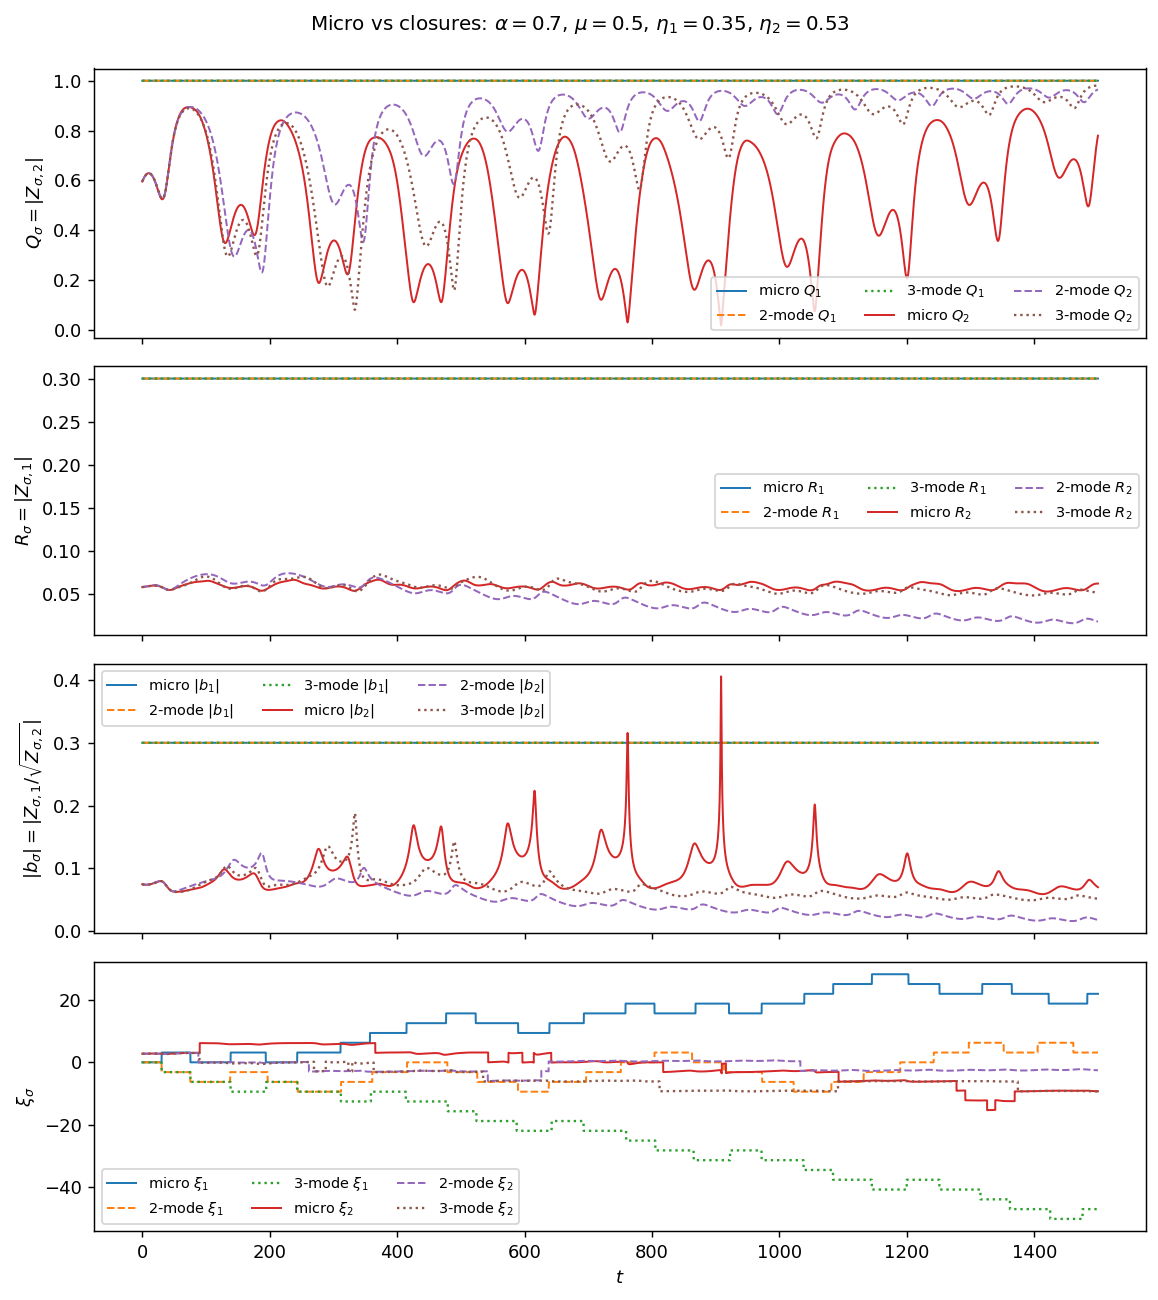

In [33]:
def plot_comparison(data, save=True):
    t = data['t']
    fig, axes = plt.subplots(4, 1, figsize=(9.0, 10.0), sharex=True)

    axes[0].plot(t, data['micro_Q1'], label=r'micro $Q_1$', lw=1.1)
    axes[0].plot(t, data['closure2_Q1'], '--', label=r'2-mode $Q_1$', lw=1.1)
    axes[0].plot(t, data['closure3_Q1'], ':', label=r'3-mode $Q_1$', lw=1.3)
    axes[0].plot(t, data['micro_Q2'], label=r'micro $Q_2$', lw=1.1)
    axes[0].plot(t, data['closure2_Q2'], '--', label=r'2-mode $Q_2$', lw=1.1)
    axes[0].plot(t, data['closure3_Q2'], ':', label=r'3-mode $Q_2$', lw=1.3)
    axes[0].set_ylabel(r'$Q_\sigma=|Z_{\sigma,2}|$')
    axes[0].legend(ncol=3, fontsize=8)

    axes[1].plot(t, data['micro_R1'], label=r'micro $R_1$', lw=1.1)
    axes[1].plot(t, data['closure2_R1'], '--', label=r'2-mode $R_1$', lw=1.1)
    axes[1].plot(t, data['closure3_R1'], ':', label=r'3-mode $R_1$', lw=1.3)
    axes[1].plot(t, data['micro_R2'], label=r'micro $R_2$', lw=1.1)
    axes[1].plot(t, data['closure2_R2'], '--', label=r'2-mode $R_2$', lw=1.1)
    axes[1].plot(t, data['closure3_R2'], ':', label=r'3-mode $R_2$', lw=1.3)
    axes[1].set_ylabel(r'$R_\sigma=|Z_{\sigma,1}|$')
    axes[1].legend(ncol=3, fontsize=8)

    axes[2].plot(t, data['micro_absb1'], label=r'micro $|b_1|$', lw=1.1)
    axes[2].plot(t, data['closure2_absb1'], '--', label=r'2-mode $|b_1|$', lw=1.1)
    axes[2].plot(t, data['closure3_absb1'], ':', label=r'3-mode $|b_1|$', lw=1.3)
    axes[2].plot(t, data['micro_absb2'], label=r'micro $|b_2|$', lw=1.1)
    axes[2].plot(t, data['closure2_absb2'], '--', label=r'2-mode $|b_2|$', lw=1.1)
    axes[2].plot(t, data['closure3_absb2'], ':', label=r'3-mode $|b_2|$', lw=1.3)
    axes[2].set_ylabel(r'$|b_\sigma|=|Z_{\sigma,1}/\sqrt{Z_{\sigma,2}}|$')
    axes[2].legend(ncol=3, fontsize=8)

    axes[3].plot(t, data['micro_xi1'], label=r'micro $\xi_1$', lw=1.1)
    axes[3].plot(t, data['closure2_xi1'], '--', label=r'2-mode $\xi_1$', lw=1.1)
    axes[3].plot(t, data['closure3_xi1'], ':', label=r'3-mode $\xi_1$', lw=1.3)
    axes[3].plot(t, data['micro_xi2'], label=r'micro $\xi_2$', lw=1.1)
    axes[3].plot(t, data['closure2_xi2'], '--', label=r'2-mode $\xi_2$', lw=1.1)
    axes[3].plot(t, data['closure3_xi2'], ':', label=r'3-mode $\xi_2$', lw=1.3)
    axes[3].set_ylabel(r'$\xi_\sigma$')
    axes[3].set_xlabel(r'$t$')
    axes[3].legend(ncol=3, fontsize=8)

    fig.suptitle(rf'Micro vs closures: $\alpha={alpha}$, $\mu={mu}$, $\eta_1={eta1_0}$, $\eta_2={eta2_0}$', y=0.995, fontsize=11)
    plt.tight_layout()
    if save:
        path = OUTDIR / 'micro_vs_two_three_mode_closures.png'
        plt.savefig(path)
        print('Saved:', path)
    plt.show()

plot_comparison(data)

## 10. Plot: $Z_3$ closure diagnostics

Saved: odd_even_outputs\Z3_closure_diagnostics.png


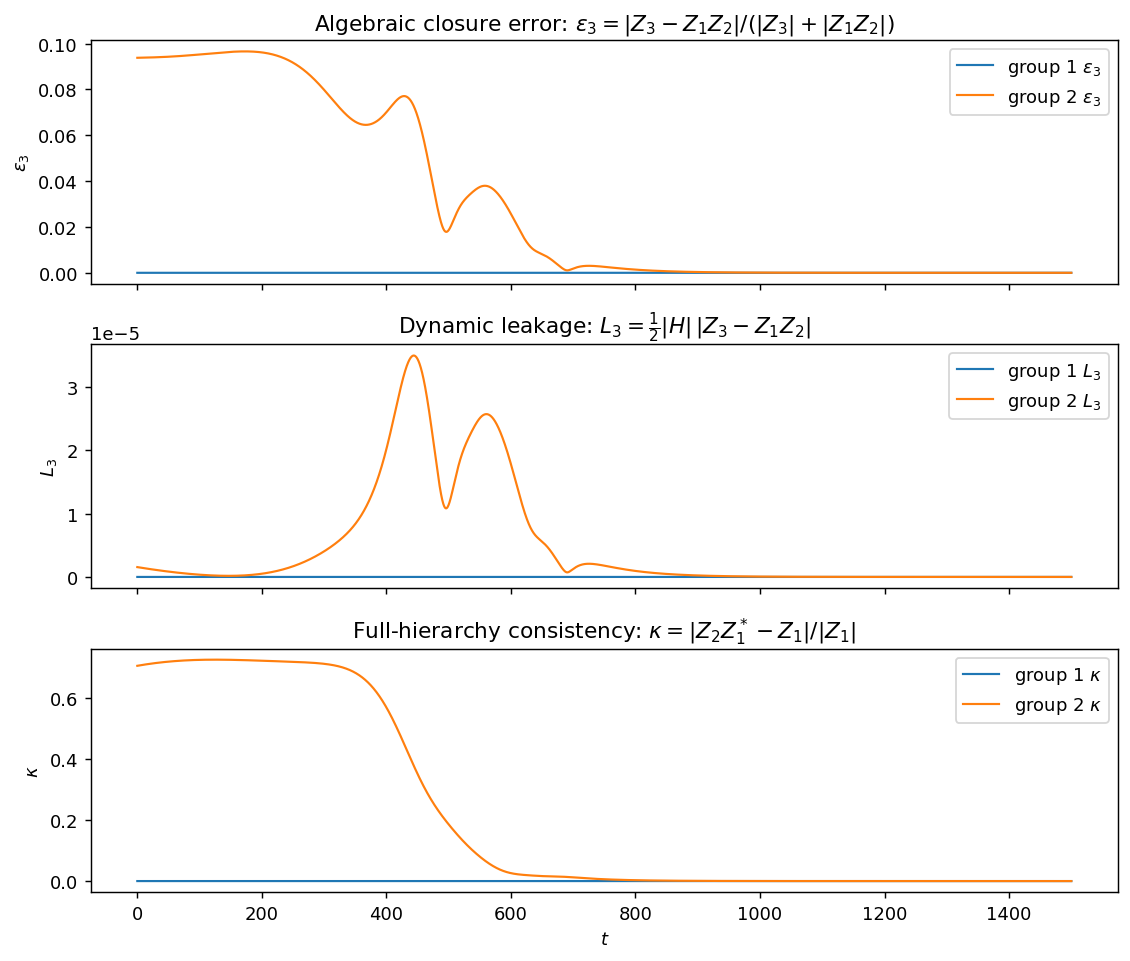

In [23]:
def plot_Z3_diagnostics(data, save=True):
    t = data['t']
    fig, axes = plt.subplots(3, 1, figsize=(8.8, 7.5), sharex=True)

    axes[0].plot(t, data['micro_eps31'], label=r'group 1 $\epsilon_3$', lw=1.2)
    axes[0].plot(t, data['micro_eps32'], label=r'group 2 $\epsilon_3$', lw=1.2)
    axes[0].set_ylabel(r'$\epsilon_3$')
    axes[0].set_title(r'Algebraic closure error: $\epsilon_3=|Z_3-Z_1Z_2|/(|Z_3|+|Z_1Z_2|)$')
    axes[0].legend()

    axes[1].plot(t, data['micro_leak31'], label=r'group 1 $L_3$', lw=1.2)
    axes[1].plot(t, data['micro_leak32'], label=r'group 2 $L_3$', lw=1.2)
    axes[1].set_ylabel(r'$L_3$')
    axes[1].set_title(r'Dynamic leakage: $L_3=\frac{1}{2} |H|\,|Z_3-Z_1Z_2|$')
    axes[1].legend()

    axes[2].plot(t, data['micro_cons1'], label=r'group 1 $\kappa$', lw=1.2)
    axes[2].plot(t, data['micro_cons2'], label=r'group 2 $\kappa$', lw=1.2)
    axes[2].set_ylabel(r'$\kappa$')
    axes[2].set_xlabel(r'$t$')
    axes[2].set_title(r'Full-hierarchy consistency: $\kappa=|Z_2Z_1^*-Z_1|/|Z_1|$')
    axes[2].legend()

    plt.tight_layout()
    if save:
        path = OUTDIR / 'Z3_closure_diagnostics.png'
        plt.savefig(path)
        print('Saved:', path)
    plt.show()

plot_Z3_diagnostics(data)

## 11. Save data

In [ ]:
np.savez_compressed(OUTDIR / 'comparison_data.npz', **data)
print('Saved:', OUTDIR / 'comparison_data.npz')

## 12. Optional parameter sweep of $Z_3$ error

필요할 때만 실행하세요. 빠른 확인을 위해 기본 grid는 작게 잡는 것을 권장합니다.

In [24]:
def sweep_Z3_error(alpha_vals, mu_vals, N1=1500, N2=1500, tmax=80.0, transient=40.0, seed=10):
    mean_eps3_g2 = np.zeros((len(alpha_vals), len(mu_vals)))
    mean_leak3_g2 = np.zeros((len(alpha_vals), len(mu_vals)))
    mean_Q2 = np.zeros((len(alpha_vals), len(mu_vals)))
    amp_Q2 = np.zeros((len(alpha_vals), len(mu_vals)))

    n_steps = int(round(tmax/dt))
    transient_step = int(round(transient/dt))
    rng_master = np.random.default_rng(seed)

    for ia, a in enumerate(alpha_vals):
        for im, m in enumerate(mu_vals):
            rng = np.random.default_rng(rng_master.integers(1, 2**31-1))
            theta1 = make_bimodal_initial_condition(N1, Q1_0, eta1_0, psi1_0, rng)
            theta2 = make_bimodal_initial_condition(N2, Q2_0, eta2_0, psi2_0, rng)

            eps3_vals, leak3_vals, Q2_vals = [], [], []
            for step in range(1, n_steps + 1):
                theta1, theta2 = rk4_micro_step(theta1, theta2, dt, a, m, omega)
                if step % record_every == 0 and step >= transient_step:
                    A1, B1, C1 = order_moments(theta1)
                    A2, B2, C2 = order_moments(theta2)
                    H2 = np.exp(-1j*a) * (B2 + m*B1)**2
                    _, eps32, leak32, _ = compute_diagnostics(A2, B2, C2, H2)
                    eps3_vals.append(eps32)
                    leak3_vals.append(leak32)
                    Q2_vals.append(np.abs(A2))

            mean_eps3_g2[ia, im] = np.mean(eps3_vals)
            mean_leak3_g2[ia, im] = np.mean(leak3_vals)
            mean_Q2[ia, im] = np.mean(Q2_vals)
            amp_Q2[ia, im] = np.max(Q2_vals) - np.min(Q2_vals)

    return {
        'alpha_vals': np.array(alpha_vals),
        'mu_vals': np.array(mu_vals),
        'mean_eps3_g2': mean_eps3_g2,
        'mean_leak3_g2': mean_leak3_g2,
        'mean_Q2': mean_Q2,
        'amp_Q2': amp_Q2,
    }

# Example:
# alpha_grid = np.linspace(0.1, 1.4, 15)
# mu_grid = np.linspace(0.1, 1.0, 15)
# sweep_data = sweep_Z3_error(alpha_grid, mu_grid)
# np.savez_compressed(OUTDIR / 'Z3_error_sweep.npz', **sweep_data)

## 13. Optional plotting for parameter sweep

In [ ]:
def plot_sweep_heatmap(sweep_data, key, title, label, save_name=None):
    alpha_vals = sweep_data['alpha_vals']
    mu_vals = sweep_data['mu_vals']
    Z = sweep_data[key]

    plt.figure(figsize=(6.6, 5.2))
    plt.imshow(Z.T, origin='lower', aspect='auto', extent=[alpha_vals[0], alpha_vals[-1], mu_vals[0], mu_vals[-1]])
    plt.colorbar(label=label)
    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$\mu$')
    plt.title(title)

    line = np.sqrt(np.sin(alpha_vals))
    mask = (line >= mu_vals[0]) & (line <= mu_vals[-1])
    plt.plot(alpha_vals[mask], line[mask], '--', lw=1.2, label=r'$\mu=\sqrt{\sin\alpha}$')
    plt.legend()
    plt.tight_layout()

    if save_name is not None:
        path = OUTDIR / save_name
        plt.savefig(path)
        print('Saved:', path)
    plt.show()

# Example:
# plot_sweep_heatmap(sweep_data, 'mean_eps3_g2', r'Mean $Z_3$ closure error, group 2', r'$\langle\epsilon_{2,3}\rangle$', 'sweep_mean_eps3_g2.png')
# plot_sweep_heatmap(sweep_data, 'mean_leak3_g2', r'Mean dynamic leakage, group 2', r'$\langle L_{2,3}\rangle$', 'sweep_mean_leak3_g2.png')